# 微博数据预处理
## 1. 导入必要的库

In [97]:
import pandas as pd
import numpy as np
import jieba
import jieba.analyse
import re
from datetime import datetime
import matplotlib.pyplot as plt
from collections import Counter
import warnings
from typing import Optional, List, Union
from pathlib import Path
from modelscope.pipelines import pipeline
from modelscope.utils.constant import Tasks
import json
from difflib import SequenceMatcher
import hashlib
import r

warnings.filterwarnings('ignore')

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

print("✅ 库导入成功")
print(f"pandas版本: {pd.__version__}")
print(f"jieba版本: {jieba.__version__}")


✅ 库导入成功
pandas版本: 2.2.2
jieba版本: 0.42.1


In [111]:
pip uninstall -y pyarrow

Note: you may need to restart the kernel to use updated packages.


### 定义预处理器类

In [82]:
class WeiboPreprocessor:
    """微博数据预处理器"""
    def __init__(self, 
                 stopwords_file_path= None,
                 user_dict_path=None):  # 新增：自定义词典文件
        """
        初始化预处理器
        
        Args:
            stopwords_file_path: 停用词文件路径
            user_dict_path: 用户自定义词典文件路径（每行一个词）
        """
        self.stopword_file = stopwords_file_path
        self.stopwords = self._load_stopwords()
        
        # 加载自定义词典（如果提供）
        if user_dict_path:
            self._load_user_dict(user_dict_path)

        self.ad_pipeline = None  # 广告过滤器实例
    
    def _load_user_dict(self, user_dict_path: str) -> None:
        """
        加载用户自定义词典
        
        Args:
            user_dict_path: 词典文件路径
        """
        try:
            jieba.load_userdict(user_dict_path)
            print(f"✅ 已加载自定义词典: {user_dict_path}")
        except Exception as e:
            print(f"⚠️ 加载自定义词典失败: {e}，继续使用默认词典")
    
    def _load_stopwords(self) -> set:
        """加载停用词(从文件中读取)"""
        stopwords = set()
        
        # 基础停用词兜底
        base_stops = {
            '的', '了', '在', '是', '我', '有', '和', '就', '不', '人', '都',
            '一', '一个', '上', '也', '很', '到', '说', '要', '去', '你', '会',
            '着', '没有', '看', '好', '自己', '这', '那', '吗', '啊', '呢',
            '把', '被', '让', '给', '跟', '与', '对', '并', '因此', '所以'
        }
        
        # 如果提供了停用词文件，尝试加载
        if self.stopword_file:
            file_path = Path(self.stopword_file)
            if file_path.exists():
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        for line in f:
                            word = line.strip()
                            if word and not word.startswith('#'):  # 跳过注释行
                                stopwords.add(word)
                    print(f"✅ 从文件加载了 {len(stopwords)} 个停用词")
                    return stopwords
                    
                except Exception as e:
                    print(f"⚠️ 读取停用词文件出错：{e}，使用基础停用词")
            else:
                print(f"⚠️ 未找到停用词文件：{self.stopword_file}，使用基础停用词")
        
        # 使用基础停用词
        stopwords.update(base_stops)
        print(f"📚 使用基础停用词，共 {len(stopwords)} 个")
        return stopwords

    def init_ad_filter(self):
        """初始化RexUniNLU广告过滤器"""
        try:
            self.ad_pipeline = pipeline(
                Tasks.siamese_uie,
                'iic/nlp_deberta_rex-uninlu_chinese-base'
            )
            print("✅ RexUniNLU广告过滤器初始化成功")
            
            # 定义广告识别的Schema
            self.ad_schema = [
                '联系方式引流',
                '商品推广',
                '限时优惠',
                '引导互动',
                '索取个人信息',
                '正常内容'
            ]
            return True
        except Exception as e:
            print(f"⚠️ RexUniNLU初始化失败: {e}")
            self.ad_pipeline = None
            return False

    def detect_ad_with_rexuninlu(self, text, threshold=0.5):
        """使用RexUniNLU检测广告"""
        if not self.ad_pipeline or not text or len(text) < 10:
            return False, 0, []
        
        try:
            result = self.ad_pipeline(
                input=text,
                schema=self.ad_schema
            )
            
            ad_labels = ['联系方式引流', '商品推广', '限时优惠', '引导互动', '索取个人信息']
            max_conf = 0
            matched_label = ""
            
            for label, matches in result.items():
                if matches and len(matches) > 0:
                    conf = matches[0].get('probability', 0)
                    if label in ad_labels and conf > max_conf:
                        max_conf = conf
                        matched_label = label
            
            is_ad = max_conf > threshold
            return is_ad, max_conf, matched_label
            
        except Exception as e:
            print(f"⚠️ RexUniNLU广告检测出错: {e}")
            return False, 0, []

    def filter_ads_hybrid(self, text, author=None):
        """混合广告过滤（规则 + RexUniNLU）"""
        if not isinstance(text, str) or len(text) < 5:
            return False, "文本过短"
        
        # 白名单
        whitelist = {'人民日报', '央视新闻', '新华网', '人民网', '中国政府网'}
        if author and author in whitelist:
            return False, "白名单账号"
        
        # 规则快速过滤
        rule_keywords = [
            '加V', '加v', '微信', 'QQ', '淘宝', '京东', '拼多多',
            '优惠券', '特价', '代购', '代理', '兼职', '日结',
            '限时', '最后一天', '手慢无', '白菜价'
        ]
        
        for keyword in rule_keywords:
            if keyword in text:
                return True, f"规则命中: {keyword}"
        
        # RexUniNLU深度分析
        is_ad, conf, label = self.detect_ad_with_rexuninlu(text)
        
        if is_ad:
            return True, f"RexUniNLU检测: {label}({conf:.2f})"
        
        return False, ""

    def clean_text(self, text):
        """清洗文本"""
        if pd.isna(text) or not isinstance(text, str):
            return ""
        # 去除url
        text = re.sub(r'http\S+|www\.\S+', '', text)
        # 去除@用户
        text = re.sub(r'@\S+', '', text)
        # 去除话题标签#
        text = re.sub(r'#', '', text)
        # 去除多余的空白符
        text = re.sub(r'\s+', ' ', text)
        # 去除标点以及非中英文字符，保留中文标点
        text = re.sub(r'[^\u4e00-\u9fff\u0041-\u005a\u0061-\u007a0-9\.,!?;:，。！？；：、]', '', text)
        # 去除空格
        text = text.strip()
        
        return text

    def segment(self, 
                text: str, 
                use_keywords: bool = False, 
                topK: int = 10, 
                cut_all: bool = False,
                min_word_len: int = 2) -> List[str]:
        """
        分词
        
        Args:
            text: 清洗后的文本
            use_keywords: 是否使用关键词提取模式
            topK: 关键词数量
            cut_all: 是否使用全模式（默认False，精确模式）
            min_word_len: 最小词长度
            
        Returns:
            分词列表
        """
        if not text:
            return []
        
        try:
            if use_keywords:
                # 关键词提取模式
                words = jieba.analyse.extract_tags(text, topK=topK, withWeight=False)
            else:
                # 精确模式分词
                words = jieba.lcut(text, cut_all=cut_all)
                # 过滤停用词和短词
                words = [w for w in words 
                        if w not in self.stopwords and len(w) >= min_word_len]
            
            return words
            
        except Exception as e:
            print(f"⚠️ 分词出错: {e}")
            return []

    def process_dataframe(self, df: pd.DataFrame, text_column: str = 'content', 
                          filter_ads: bool = False, 
                          author_column: str = None,
                          deduplicate: bool = False,
                          dedup_method: str = 'semantic') -> pd.DataFrame:
        """
        批量处理DataFrame
        
        Args:
            df: 原始数据DataFrame
            text_column: 文本列名
            filter_ads: 是否过滤广告 
            author_column: 作者列名（用于白名单） 
            deduplicate: 是否去重 
            dedup_method: 去重方法 
        
        Returns:
            处理后的DataFrame
        """
        df = df.copy()
        
        # ========== 广告过滤 ==========
        if filter_ads:
            print("\n🚫 开始广告过滤...")
            if not hasattr(self, 'ad_pipeline') or self.ad_pipeline is None:
                self.init_ad_filter()
            
            keep_indices = []
            filter_reasons = []
            
            for idx, row in df.iterrows():
                text = row[text_column]
                author = row[author_column] if author_column else None
                
                should_filter, reason = self.filter_ads_hybrid(text, author)
                
                if not should_filter:
                    keep_indices.append(idx)
                filter_reasons.append(reason)
            
            df['ad_filter_reason'] = filter_reasons
            original_len = len(df)
            df = df.iloc[keep_indices].reset_index(drop=True)
            print(f"  广告过滤: 保留了 {len(df)}/{original_len} 条 ({len(df)/original_len*100:.1f}%)")
        
        # 清洗文本
        df['cleaned_content'] = df[text_column].apply(self.clean_text)
        
        # 过滤空内容
        original_len = len(df)
        df = df[df['cleaned_content'].str.len() > 0].copy()
        print(f"  过滤空内容: {original_len - len(df)} 条")
        
        # 分词
        df['words'] = df['cleaned_content'].apply(self.segment)
        df['words_str'] = df['words'].apply(lambda x: ' '.join(x))
        
        # ========== 去重 ==========
        if deduplicate:
            print("\n🔄 开始去重...")
            deduplicator = DuplicateDetector(similarity_threshold=0.85)
            df = deduplicator.deduplicate_dataframe(df, text_column='cleaned_content', method=dedup_method)
        
        print(f"\n✅ 处理完成，剩余 {len(df)} 条数据")
        return df
    
    def parse_timestamp(self, timestamp):
        """解析时间戳"""
        try:
            if pd.isna(timestamp):
                return None
            
            ts = int(timestamp)
            if ts > 1e12:  # 13位毫秒时间戳
                return datetime.fromtimestamp(ts / 1000)
            else:  # 10位秒时间戳
                return datetime.fromtimestamp(ts)
        except:
            return None
    
# # 创建预处理器实例
# preprocessor = WeiboPreprocessor(stopwords_file_path='E:\\pycharm\\code\\SocialMediaAnalysis\\words\\stopwords_hit.txt',
#                                  user_dict_path='E:\\pycharm\\code\\SocialMediaAnalysis\\words\\user_dict.txt')
# print("✅ 预处理器初始化完成")            

✅ 从文件加载了 1293 个停用词
✅ 已加载自定义词典: E:\pycharm\code\SocialMediaAnalysis\words\user_dict.txt
✅ 预处理器初始化完成


In [ ]:
class DuplicateDetector:
    """重复内容检测器"""
    
    def __init__(self, similarity_threshold=0.85):
        self.similarity_threshold = similarity_threshold
        self.seen_texts = []
        self.seen_hashes = set()
    
    def normalize_for_dedup(self, text):
        """为去重做规范化"""
        if not isinstance(text, str):
            return ""
        text = text.lower()
        text = re.sub(r'\s+', '', text)
        text = re.sub(r'[^\w\u4e00-\u9fff]', '', text)
        return text
    
    def compute_hash(self, text):
        """计算文本哈希"""
        if not text:
            return None
        return hashlib.md5(text.encode('utf-8')).hexdigest()
    
    def is_duplicate_simple(self, text):
        """简单去重：基于完全匹配"""
        if not text:
            return False
        norm_text = self.normalize_for_dedup(text)
        text_hash = self.compute_hash(norm_text)
        if text_hash in self.seen_hashes:
            return True
        self.seen_hashes.add(text_hash)
        return False
    
    def is_duplicate_semantic(self, text):
        """语义去重：基于文本相似度"""
        if not text:
            return False
        norm_text = self.normalize_for_dedup(text)
        for seen in self.seen_texts:
            similarity = SequenceMatcher(None, norm_text, seen).ratio()
            if similarity > self.similarity_threshold:
                return True
        self.seen_texts.append(norm_text)
        return False
    
    def deduplicate_dataframe(self, df, text_column='cleaned_content', 
                              method='semantic'):
        """对DataFrame去重"""
        self.seen_hashes = set()
        self.seen_texts = []
        
        keep_indices = []
        duplicate_indices = []
        
        print(f"\n🔍 开始去重 (方法: {method})...")
        
        for idx, text in enumerate(df[text_column]):
            if pd.isna(text) or not isinstance(text, str):
                keep_indices.append(idx)
                continue
            
            if method == 'simple':
                is_dup = self.is_duplicate_simple(text)
            else:
                is_dup = self.is_duplicate_semantic(text)
            
            if is_dup:
                duplicate_indices.append(idx)
            else:
                keep_indices.append(idx)
        
        df['is_duplicate'] = False
        df.loc[duplicate_indices, 'is_duplicate'] = True
        
        result_df = df.iloc[keep_indices].reset_index(drop=True)
        
        print(f"  去重前: {len(df)} 条")
        print(f"  保留: {len(result_df)} 条")
        print(f"  重复: {len(duplicate_indices)} 条 ({len(duplicate_indices)/len(df)*100:.1f}%)")
        
        return result_df

In [84]:
import pandas as pd
import os
import glob
import re
from typing import Optional, List

class WeiboDataLoader:
    """微博数据加载器"""
    
    def __init__(self, data_dir: str = None):
        """
        初始化数据加载器
        
        Args:
            data_dir: 默认数据目录
        """
        self.data_dir = data_dir
        self.encoding = 'utf-8-sig'
    
    def load_posts(self, 
                   file_path: Optional[str] = None, 
                   date: Optional[str] = None,
                   pattern: str = '*_contents_*.csv') -> pd.DataFrame:
        """
        加载帖子数据（支持 search_contents 和 creator_contents）
        
        Args:
            file_path: 单个文件路径（优先使用）
            date: 指定日期，如 '2026-03-02'
            pattern: 文件名匹配模式，默认 '*_contents_*.csv'
        
        Returns:
            合并后的帖子DataFrame
        """
        return self._load_data(
            file_path=file_path,
            date=date,
            pattern=pattern,
            data_type='posts'
        )
    
    def load_comments(self,
                      file_path: Optional[str] = None,
                      date: Optional[str] = None,
                      pattern: str = 'search_comments_*.csv') -> pd.DataFrame:
        """
        加载评论数据
        
        Args:
            file_path: 单个文件路径（优先使用）
            date: 指定日期，如 '2026-03-02'
            pattern: 文件名匹配模式，默认 'search_comments_*.csv'
        
        Returns:
            合并后的评论DataFrame
        """
        return self._load_data(
            file_path=file_path,
            date=date,
            pattern=pattern,
            data_type='comments'
        )
    
    def load_creators(self,
                      file_path: Optional[str] = None,
                      date: Optional[str] = None,
                      pattern: str = 'creator_creators_*.csv') -> pd.DataFrame:
        """
        加载创作者/用户数据
        
        Args:
            file_path: 单个文件路径（优先使用）
            date: 指定日期，如 '2026-03-02'
            pattern: 文件名匹配模式，默认 'creator_creators_*.csv'
        
        Returns:
            合并后的创作者DataFrame
        """
        return self._load_data(
            file_path=file_path,
            date=date,
            pattern=pattern,
            data_type='creators'
        )
    
    def _load_data(self, 
                   file_path: Optional[str],
                   date: Optional[str],
                   pattern: str,
                   data_type: str) -> pd.DataFrame:
        """
        内部方法：加载数据
        """
        dfs = []
        
        # 1. 如果指定了具体文件
        if file_path:
            if os.path.exists(file_path):
                df = self._read_single_file(file_path)
                if df is not None:
                    dfs.append(df)
                    print(f"✅ 加载文件: {os.path.basename(file_path)}")
            else:
                print(f"❌ 文件不存在: {file_path}")
        
        # 2. 如果指定了日期
        elif date and self.data_dir:
            # 根据data_type确定可能的文件名
            possible_filenames = []
            
            if data_type == 'posts':
                # 帖子有两种可能
                possible_filenames = [
                    f"search_contents_{date}.csv",
                    f"creator_contents_{date}.csv"
                ]
            elif data_type == 'comments':
                # 评论只有一种
                possible_filenames = [f"search_comments_{date}.csv"]
            elif data_type == 'creators':
                # 创作者只有一种
                possible_filenames = [f"creator_creators_{date}.csv"]
            
            loaded = False
            for filename in possible_filenames:
                file_path = os.path.join(self.data_dir, filename)
                if os.path.exists(file_path):
                    df = self._read_single_file(file_path)
                    if df is not None:
                        dfs.append(df)
                        print(f"✅ 加载文件: {filename}")
                        loaded = True
                        # 如果是帖子且找到了一个，是否继续找另一个？这里选择继续找
                        if data_type != 'posts':
                            break
            
            if not loaded:
                print(f"❌ 未找到日期 {date} 的 {data_type} 文件")
        
        # 3. 否则加载目录下所有匹配的文件
        elif self.data_dir:
            file_pattern = os.path.join(self.data_dir, pattern)
            files = sorted(glob.glob(file_pattern))
            
            if not files:
                print(f"⚠️ 在 {self.data_dir} 中没有找到匹配 {pattern} 的文件")
            else:
                print(f"📁 找到 {len(files)} 个 {data_type} 文件:")
                for file in files:
                    df = self._read_single_file(file)
                    if df is not None:
                        dfs.append(df)
                        print(f"  ✅ {os.path.basename(file)}")
        
        else:
            print("❌ 请指定 file_path、date 或初始化时设置 data_dir")
            return pd.DataFrame()
        
        # 合并所有DataFrame
        if dfs:
            result = pd.concat(dfs, ignore_index=True)
            print(f"\n📊 总计加载 {len(result)} 条 {data_type} 数据")
            return result
        else:
            print(f"⚠️ 没有加载到任何 {data_type} 数据")
            return pd.DataFrame()
    
    def _read_single_file(self, file_path: str) -> Optional[pd.DataFrame]:
        """读取单个CSV文件"""
        try:
            df = pd.read_csv(file_path, encoding=self.encoding)
            # 添加来源信息
            df['source_file'] = os.path.basename(file_path)
            
            # 根据文件名判断类型
            if 'search_contents' in file_path:
                df['data_type'] = 'search_post'
            elif 'creator_contents' in file_path:
                df['data_type'] = 'creator_post'
            elif 'search_comments' in file_path:
                df['data_type'] = 'search_comment'
            elif 'creator_creators' in file_path:
                df['data_type'] = 'creator_info'
            
            return df
        except Exception as e:
            print(f"❌ 读取失败 {os.path.basename(file_path)}: {e}")
            return None
    
    def get_available_dates(self, pattern: str = '*_*_*.csv') -> List[str]:
        """获取可用的日期列表"""
        if not self.data_dir:
            return []
        
        files = glob.glob(os.path.join(self.data_dir, pattern))
        dates = set()
        
        for file in files:
            basename = os.path.basename(file)
            # 匹配日期格式
            match = re.search(r'\d{4}-\d{2}-\d{2}', basename)
            if match:
                dates.add(match.group())
        
        return sorted(list(dates))
    
    def get_summary(self) -> dict:
        """获取数据目录的摘要信息"""
        summary = {}
        
        if not self.data_dir:
            return summary
        
        # 统计各种文件
        summary['search_posts'] = len(glob.glob(os.path.join(self.data_dir, 'search_contents_*.csv')))
        summary['creator_posts'] = len(glob.glob(os.path.join(self.data_dir, 'creator_contents_*.csv')))
        summary['search_comments'] = len(glob.glob(os.path.join(self.data_dir, 'search_comments_*.csv')))
        summary['creator_creators'] = len(glob.glob(os.path.join(self.data_dir, 'creator_creators_*.csv')))
        
        # 获取日期列表
        summary['all_dates'] = self.get_available_dates()
        
        return summary


# # 使用示例
# if __name__ == "__main__":
#     # 初始化加载器
#     loader = WeiboDataLoader(data_dir=r"E:\MyProjects\MediaCrawler\data\weibo\csv")
    
#     # 1. 查看目录摘要
#     print("📋 数据目录摘要:")
#     summary = loader.get_summary()
#     print(f"搜索帖子文件数: {summary.get('search_posts', 0)}")
#     print(f"创作者帖子文件数: {summary.get('creator_posts', 0)}")
#     print(f"评论文件数: {summary.get('search_comments', 0)}")
#     print(f"创作者信息文件数: {summary.get('creator_creators', 0)}")
#     print(f"所有可用日期: {summary.get('all_dates', [])}")
    
#     print("\n" + "="*60)
    
#     # 2. 加载评论（只有一种）
#     print("📥 加载评论数据:")
#     df_comments = loader.load_comments()  # 加载所有评论
#     print(f"评论数据形状: {df_comments.shape if not df_comments.empty else '空'}")
    
#     if not df_comments.empty:
#         print(f"评论列名: {df_comments.columns.tolist()}")
    
#     print("\n" + "="*60)
    
#     # 3. 加载指定日期的评论
#     print("📥 加载指定日期的评论:")
#     df_comments_date = loader.load_comments(date='2026-03-02')
#     print(f"2026-03-02 评论数据形状: {df_comments_date.shape if not df_comments_date.empty else '空'}")
    
#     print("\n" + "="*60)
    
#     # 4. 加载帖子（有两种可能）
#     print("📥 加载帖子数据:")
#     df_posts = loader.load_posts()  # 加载所有帖子
#     print(f"帖子数据形状: {df_posts.shape if not df_posts.empty else '空'}")
    
#     if not df_posts.empty:
#         # 按类型统计
#         if 'data_type' in df_posts.columns:
#             print("\n帖子类型分布:")
#             print(df_posts['data_type'].value_counts())

### 词频统计类


✅ 从文件加载了 1293 个停用词
✅ 已加载自定义词典: E:\pycharm\code\SocialMediaAnalysis\words\user_dict.txt
📊 词频统计开始

📝 统计帖子词频...
📁 找到 4 个 posts 文件:
  ✅ creator_contents_2026-03-03.csv
  ✅ creator_contents_2026-03-04.csv
  ✅ search_contents_2026-03-02.csv
  ✅ search_contents_2026-03-03.csv

📊 总计加载 2168 条 posts 数据
📊 正在统计 posts_all 的词频...
✅ posts_all 词频统计完成
   总词数: 69649
   唯一词数: 17494

💬 统计评论词频...
📁 找到 2 个 comments 文件:
  ✅ search_comments_2026-03-02.csv
  ✅ search_comments_2026-03-03.csv

📊 总计加载 1766 条 comments 数据
📊 正在统计 comments_all 的词频...
✅ comments_all 词频统计完成
   总词数: 9543
   唯一词数: 4402

👤 统计创作者词频...
📁 找到 2 个 creators 文件:
  ✅ creator_creators_2026-03-03.csv
  ✅ creator_creators_2026-03-04.csv

📊 总计加载 10 条 creators 数据
📊 正在统计 creators_all 的词频...
✅ creators_all 词频统计完成
   总词数: 47
   唯一词数: 43

📅 统计指定日期的词频...
✅ 加载文件: search_contents_2026-03-02.csv

📊 总计加载 15 条 posts 数据
📊 正在统计 posts_2026-03-02 的词频...
✅ posts_2026-03-02 词频统计完成
   总词数: 358
   唯一词数: 264


📋 词频统计摘要:
            dataset  total_words  unique_words top

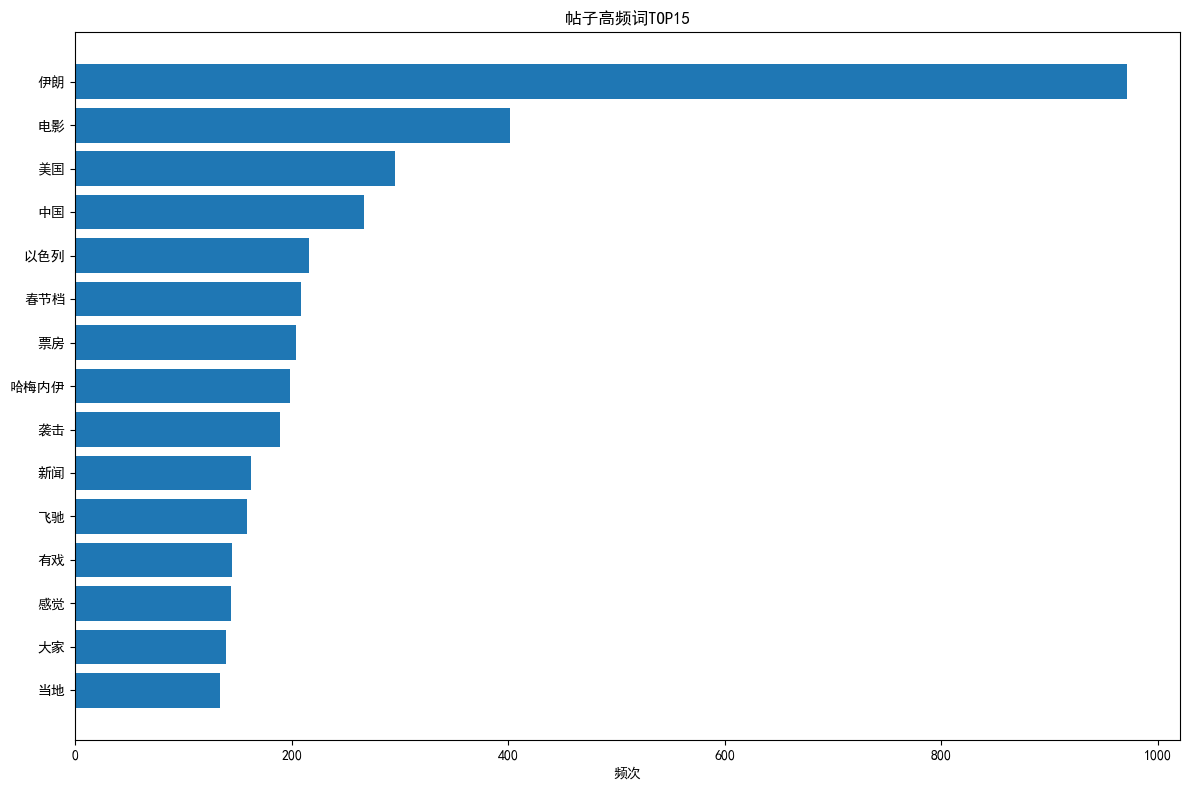

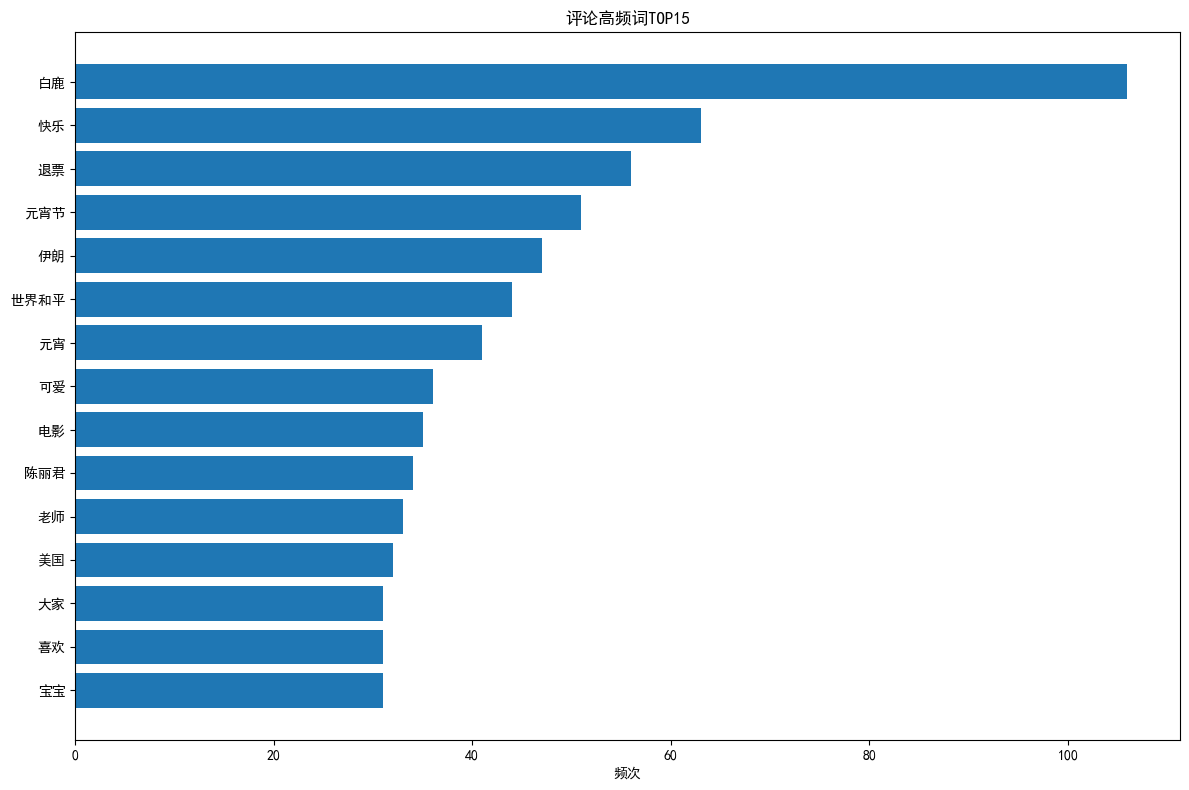


✅ 词频统计完成！


In [86]:
import jieba
import jieba.analyse
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import os

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

class WeiboWordFrequency:
    """微博词频统计类"""
    
    def __init__(self, preprocessor: WeiboPreprocessor, data_loader: WeiboDataLoader):
        """
        初始化词频统计器
        
        Args:
            preprocessor: 预处理器实例
            data_loader: 数据加载器实例
        """
        self.preprocessor = preprocessor
        self.data_loader = data_loader
        self.freq_results = {}  # 存储词频结果
    
    def compute_frequency(self, 
                         texts: pd.Series, 
                         name: str = 'default',
                         use_keywords: bool = False,
                         topN: int = 100) -> pd.DataFrame:
        """
        计算文本的词频
        
        Args:
            texts: 文本Series
            name: 数据集名称（用于标识）
            use_keywords: 是否使用关键词提取模式
            topN: 保留前N个词
        
        Returns:
            词频DataFrame
        """
        all_words = []
        
        print(f"📊 正在统计 {name} 的词频...")
        
        for text in texts:
            if pd.isna(text) or not isinstance(text, str):
                continue
            
            # 清洗文本
            cleaned = self.preprocessor.clean_text(text)
            
            # 分词
            words = self.preprocessor.segment(cleaned, use_keywords=use_keywords)
            
            all_words.extend(words)
        
        # 统计词频
        word_counter = Counter(all_words)
        
        # 将频次元组转成DataFrame
        df_freq = pd.DataFrame(word_counter.most_common(topN), 
                              columns=['word', 'frequency'])
        
        # 添加占比列
        total_words = sum(word_counter.values())
        df_freq['percentage'] = (df_freq['frequency'] / total_words * 100).round(4)
        
        # 保存结果
        self.freq_results[name] = {
            'df': df_freq,
            'counter': word_counter,
            'total_words': total_words,
            'unique_words': len(word_counter)
        }
        
        print(f"✅ {name} 词频统计完成")
        print(f"   总词数: {total_words}")
        print(f"   唯一词数: {len(word_counter)}")
        
        return df_freq
    
    def compute_from_dataframe(self,
                              df: pd.DataFrame,
                              text_column: str = 'content',
                              name: str = 'dataset',
                              use_keywords: bool = False,
                              topN: int = 100) -> pd.DataFrame:
        """
        从DataFrame中计算词频
        
        Args:
            df: 数据DataFrame
            text_column: 文本列名
            name: 数据集名称
            use_keywords: 是否使用关键词提取
            topN: 保留前N个词
        
        Returns:
            词频DataFrame
        """
        if text_column not in df.columns:
            print(f"❌ 列 {text_column} 不存在")
            return pd.DataFrame()
        
        return self.compute_frequency(
            texts=df[text_column],
            name=name,
            use_keywords=use_keywords,
            topN=topN
        )
    
    def compute_posts_frequency(self,
                               date: Optional[str] = None,
                               source: str = 'all',
                               use_keywords: bool = False,
                               topN: int = 100) -> pd.DataFrame:
        """
        计算帖子词频
        
        Args:
            date: 指定日期
            source: 'search' 或 'creator' 或 'all'
            use_keywords: 是否使用关键词提取
            topN: 保留前N个词
        
        Returns:
            词频DataFrame
        """
        # 加载帖子数据
        if date:
            df = self.data_loader.load_posts(date=date)
            name = f"posts_{date}"
        else:
            df = self.data_loader.load_posts()
            name = "posts_all"
        
        if df.empty:
            print("❌ 没有加载到帖子数据")
            return pd.DataFrame()
        
        # 如果指定了source，进行过滤
        if source != 'all' and 'data_type' in df.columns:
            if source == 'search':
                df = df[df['data_type'] == 'search_post']
                name += "_search"
            elif source == 'creator':
                df = df[df['data_type'] == 'creator_post']
                name += "_creator"
        
        return self.compute_from_dataframe(
            df=df,
            text_column='content',
            name=name,
            use_keywords=use_keywords,
            topN=topN
        )
    
    def compute_comments_frequency(self,
                                  date: Optional[str] = None,
                                  use_keywords: bool = False,
                                  topN: int = 100) -> pd.DataFrame:
        """
        计算评论词频
        
        Args:
            date: 指定日期
            use_keywords: 是否使用关键词提取
            topN: 保留前N个词
        
        Returns:
            词频DataFrame
        """
        # 加载评论数据
        if date:
            df = self.data_loader.load_comments(date=date)
            name = f"comments_{date}"
        else:
            df = self.data_loader.load_comments()
            name = "comments_all"
        
        if df.empty:
            print("❌ 没有加载到评论数据")
            return pd.DataFrame()
        
        return self.compute_from_dataframe(
            df=df,
            text_column='content',
            name=name,
            use_keywords=use_keywords,
            topN=topN
        )
    
    def compute_creators_frequency(self,
                                   date: Optional[str] = None,
                                   use_keywords: bool = False,
                                   topN: int = 100) -> pd.DataFrame:
        """
        计算创作者描述词频
        
        Args:
            date: 指定日期
            use_keywords: 是否使用关键词提取
            topN: 保留前N个词
        
        Returns:
            词频DataFrame
        """
        # 加载创作者数据
        if date:
            df = self.data_loader.load_creators(date=date)
            name = f"creators_{date}"
        else:
            df = self.data_loader.load_creators()
            name = "creators_all"
        
        if df.empty:
            print("❌ 没有加载到创作者数据")
            return pd.DataFrame()
        
        # 如果有desc列，用desc；否则用nickname或其他
        text_column = 'desc' if 'desc' in df.columns else 'nickname'
        
        return self.compute_from_dataframe(
            df=df,
            text_column=text_column,
            name=name,
            use_keywords=use_keywords,
            topN=topN
        )
    
    def save_frequency_table(self, 
                            name: str, 
                            output_dir: str = 'E:\\pycharm\\code\\SocialMediaAnalysis\\words',
                            save_csv: bool = True,
                            save_excel: bool = False) -> str:
        """
        保存词频表
        
        Args:
            name: 数据集名称
            output_dir: 输出目录
            save_csv: 是否保存CSV
            save_excel: 是否保存Excel
        
        Returns:
            保存的文件路径
        """
        if name not in self.freq_results:
            print(f"❌ 没有找到 {name} 的词频结果")
            return ""
        
        # 创建输出目录
        os.makedirs(output_dir, exist_ok=True)
        
        df = self.freq_results[name]['df']
        stats = self.freq_results[name]
        
        # 添加统计信息行
        df_with_stats = df.copy()
        stats_row = pd.DataFrame({
            'word': ['--- 统计信息 ---', f'总词数: {stats["total_words"]}', 
                    f'唯一词数: {stats["unique_words"]}'],
            'frequency': ['', '', ''],
            'percentage': ['', '', '']
        })
        df_with_stats = pd.concat([stats_row, df_with_stats], ignore_index=True)
        
        # 保存文件
        if save_csv:
            csv_path = os.path.join(output_dir, f'{name}_frequency.csv')
            df_with_stats.to_csv(csv_path, index=False, encoding='utf-8-sig')
            print(f"✅ 词频表已保存: {csv_path}")
        
        if save_excel:
            excel_path = os.path.join(output_dir, f'{name}_frequency.xlsx')
            df_with_stats.to_excel(excel_path, index=False)
            print(f"✅ 词频表已保存: {excel_path}")
        
        return csv_path if save_csv else excel_path
    
    def save_all_frequency_tables(self, output_dir: str = 'E:\\pycharm\\code\\SocialMediaAnalysis\\words'):
        """保存所有词频表"""
        for name in self.freq_results:
            self.save_frequency_table(name, output_dir)
    
    def compare_frequency(self, names: List[str], topN: int = 10) -> pd.DataFrame:
        """
        对比多个数据集的词频
        
        Args:
            names: 数据集名称列表
            topN: 对比前N个词
        
        Returns:
            对比DataFrame
        """
        comparison = {}
        
        for name in names:
            if name in self.freq_results:
                df = self.freq_results[name]['df'].head(topN)
                comparison[name] = df['word'].tolist()
        
        return pd.DataFrame(comparison)
    
    def plot_top_words(self, 
                      name: str, 
                      topN: int = 20, 
                      figsize: tuple = (12, 8),
                      title: str = None) -> None:
        """
        绘制词频柱状图
        
        Args:
            name: 数据集名称
            topN: 显示前N个词
            figsize: 图表大小
            title: 图表标题
        """
        if name not in self.freq_results:
            print(f"❌ 没有找到 {name} 的词频结果")
            return
        
        df = self.freq_results[name]['df'].head(topN)
        
        plt.figure(figsize=figsize)
        
        # 水平柱状图
        plt.barh(range(len(df)), df['frequency'][::-1])
        plt.yticks(range(len(df)), df['word'][::-1])
        
        plt.xlabel('频次')
        plt.title(title or f'{name} 高频词TOP{topN}')
        plt.tight_layout()
        plt.show()
    
    def get_summary(self) -> pd.DataFrame:
        """获取词频统计摘要"""
        summary = []
        
        for name, data in self.freq_results.items():
            summary.append({
                'dataset': name,
                'total_words': data['total_words'],
                'unique_words': data['unique_words'],
                'top_word': data['df'].iloc[0]['word'] if not data['df'].empty else '',
                'top_freq': data['df'].iloc[0]['frequency'] if not data['df'].empty else 0
            })
        
        return pd.DataFrame(summary)


# 使用示例
if __name__ == "__main__":
    # 1. 初始化各个类
    preprocessor = WeiboPreprocessor(stopwords_file_path='E:\\pycharm\\code\\SocialMediaAnalysis\\words\\stopwords_hit.txt',
                                     user_dict_path='E:\\pycharm\\code\\SocialMediaAnalysis\\words\\user_dict.txt')
    
    data_loader = WeiboDataLoader(data_dir=r"E:\MyProjects\MediaCrawler\data\weibo\csv")
    word_freq = WeiboWordFrequency(preprocessor, data_loader)
    
    print("="*60)
    print("📊 词频统计开始")
    print("="*60)
    
    # 2. 统计所有帖子的词频
    print("\n📝 统计帖子词频...")
    df_posts_freq = word_freq.compute_posts_frequency(use_keywords=False)
    
    # 3. 统计所有评论的词频
    print("\n💬 统计评论词频...")
    df_comments_freq = word_freq.compute_comments_frequency(use_keywords=False)
    
    # 4. 统计创作者信息的词频
    print("\n👤 统计创作者词频...")
    df_creators_freq = word_freq.compute_creators_frequency(use_keywords=False)
    
    # 5. 按日期统计（可选）
    print("\n📅 统计指定日期的词频...")
    df_posts_20260302 = word_freq.compute_posts_frequency(date='2026-03-02', use_keywords=False)
    
    print("\n" + "="*60)
    
    # 6. 查看摘要
    print("\n📋 词频统计摘要:")
    summary = word_freq.get_summary()
    print(summary)
    
    # 7. 显示前10个词
    print("\n📈 帖子高频词TOP10:")
    print(df_posts_freq.head(10))
    
    print("\n📈 评论高频词TOP10:")
    print(df_comments_freq.head(10))
    
    # 8. 保存所有词频表
    print("\n💾 保存词频表...")
    word_freq.save_all_frequency_tables()
    
    # 9. 绘制词频图
    print("\n🎨 绘制词频图...")
    word_freq.plot_top_words('posts_all', topN=15, title='帖子高频词TOP15')
    word_freq.plot_top_words('comments_all', topN=15, title='评论高频词TOP15')
    
    print("\n✅ 词频统计完成！")

In [88]:
# ============================================
# 情感分析数据准备（只保留必要部分）
# ============================================

import os
import pandas as pd

# 创建保存目录
output_dir = 'E:\\pycharm\\code\\SocialMediaAnalysis\\words\\cleaned_data'
os.makedirs(output_dir, exist_ok=True)

# 重新加载原始数据
loader = WeiboDataLoader(data_dir=r"E:\\MyProjects\\MediaCrawler\\data\\weibo\\csv")

print("="*60)
print("情感分析数据准备")
print("="*60)

# 1. 清洗帖子数据
print("\n📝 清洗帖子数据...")
df_posts_raw = loader.load_posts()
df_posts_cleaned = preprocessor.process_dataframe(df_posts_raw, text_column='content')
df_posts_cleaned.to_csv(f'{output_dir}/posts_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"✅ 帖子清洗完成: {len(df_posts_cleaned)} 条")
print(f"   包含字段: {list(df_posts_cleaned.columns)}")

# 2. 清洗评论数据
print("\n💬 清洗评论数据...")
df_comments_raw = loader.load_comments()
df_comments_cleaned = preprocessor.process_dataframe(df_comments_raw, text_column='content')
df_comments_cleaned.to_csv(f'{output_dir}/comments_cleaned.csv', index=False, encoding='utf-8-sig')
print(f"✅ 评论清洗完成: {len(df_comments_cleaned)} 条")
print(f"   包含字段: {list(df_comments_cleaned.columns)}")

# 3. 保存词频（用于参考）
print("\n📊 保存词频统计...")
word_freq.save_all_frequency_tables()
print("✅ 词频统计已保存")

print("\n" + "="*60)
print("✅ 情感分析数据准备完成！")
print(f"📁 数据位置: {output_dir}")
print("📌 情感分析需要的主要字段: cleaned_content")
print("="*60)

# 显示数据预览
print("\n🔍 帖子数据预览（前2条）:")
print(df_posts_cleaned[['content', 'cleaned_content', 'words']].head(2))

print("\n🔍 评论数据预览（前2条）:")
print(df_comments_cleaned[['content', 'cleaned_content', 'words']].head(2))

情感分析数据准备

📝 清洗帖子数据...
📁 找到 4 个 posts 文件:
  ✅ creator_contents_2026-03-03.csv
  ✅ creator_contents_2026-03-04.csv
  ✅ search_contents_2026-03-02.csv
  ✅ search_contents_2026-03-03.csv

📊 总计加载 2168 条 posts 数据
✅ 帖子清洗完成: 2151 条
   包含字段: ['note_id', 'content', 'create_time', 'create_date_time', 'liked_count', 'comments_count', 'shared_count', 'last_modify_ts', 'note_url', 'ip_location', 'user_id', 'nickname', 'gender', 'profile_url', 'avatar', 'source_keyword', 'source_file', 'data_type', 'cleaned_content', 'words', 'words_str']

💬 清洗评论数据...
📁 找到 2 个 comments 文件:
  ✅ search_comments_2026-03-02.csv
  ✅ search_comments_2026-03-03.csv

📊 总计加载 1766 条 comments 数据
✅ 评论清洗完成: 1683 条
   包含字段: ['comment_id', 'create_time', 'create_date_time', 'note_id', 'content', 'sub_comment_count', 'comment_like_count', 'last_modify_ts', 'ip_location', 'parent_comment_id', 'user_id', 'nickname', 'gender', 'profile_url', 'avatar', 'source_file', 'data_type', 'cleaned_content', 'words', 'words_str']

📊 保存词频统计...
✅ 词